<a href="https://colab.research.google.com/github/vikasverma9721/Machine-Learning-Models/blob/main/Auto_MPG_Linear_Regression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Import Libraries.***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = '/content/drive/MyDrive/Dataset/Auto MPG Car.csv'

In [ ]:
df = pd.read_csv(df1)

***Data Pre-Proccessing.***

In [ ]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
17961,False
17962,False
17963,False
17964,False


In [ ]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [ ]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [ ]:
df.shape

(17966, 9)

In [ ]:
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

(17812, 9)

***Exploratory Data Analysis.***

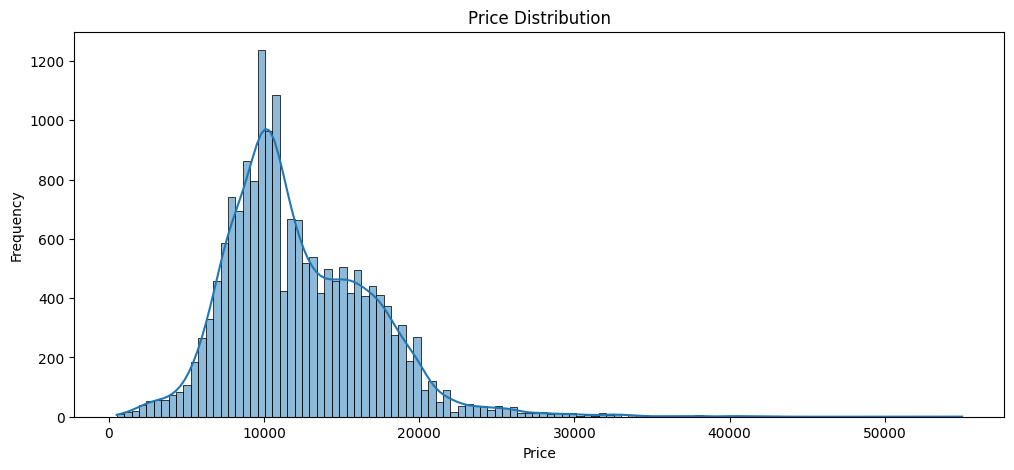

In [ ]:
plt.figure(figsize = (12,5))
sns.histplot(df['price'], kde = True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

***Line Plot***

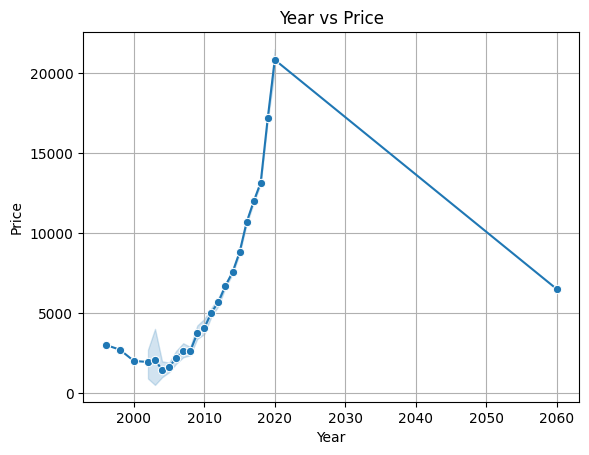

In [ ]:
sns.lineplot(data = df, x = 'year', y = 'price', marker = 'o')
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)
plt.show()

***Scatter Plot***

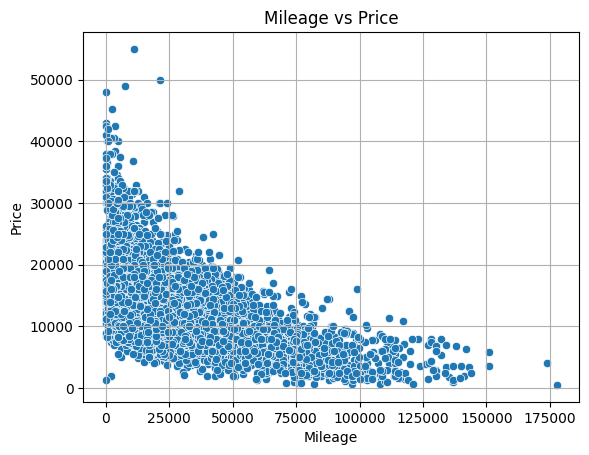

In [ ]:
sns.scatterplot(data = df, x = 'mileage', y = 'price')
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.grid(True)
plt.show()

***Heat Map***

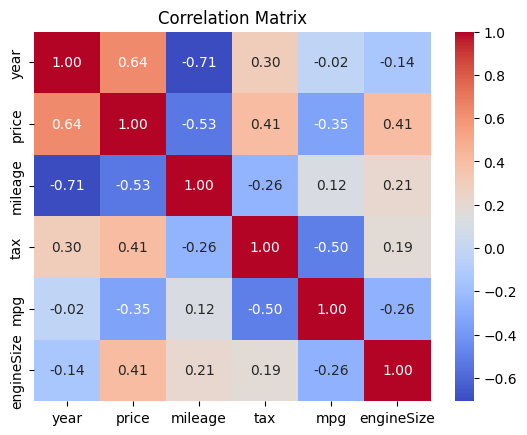

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot = True, cmap = 'coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

***Pair Plot***

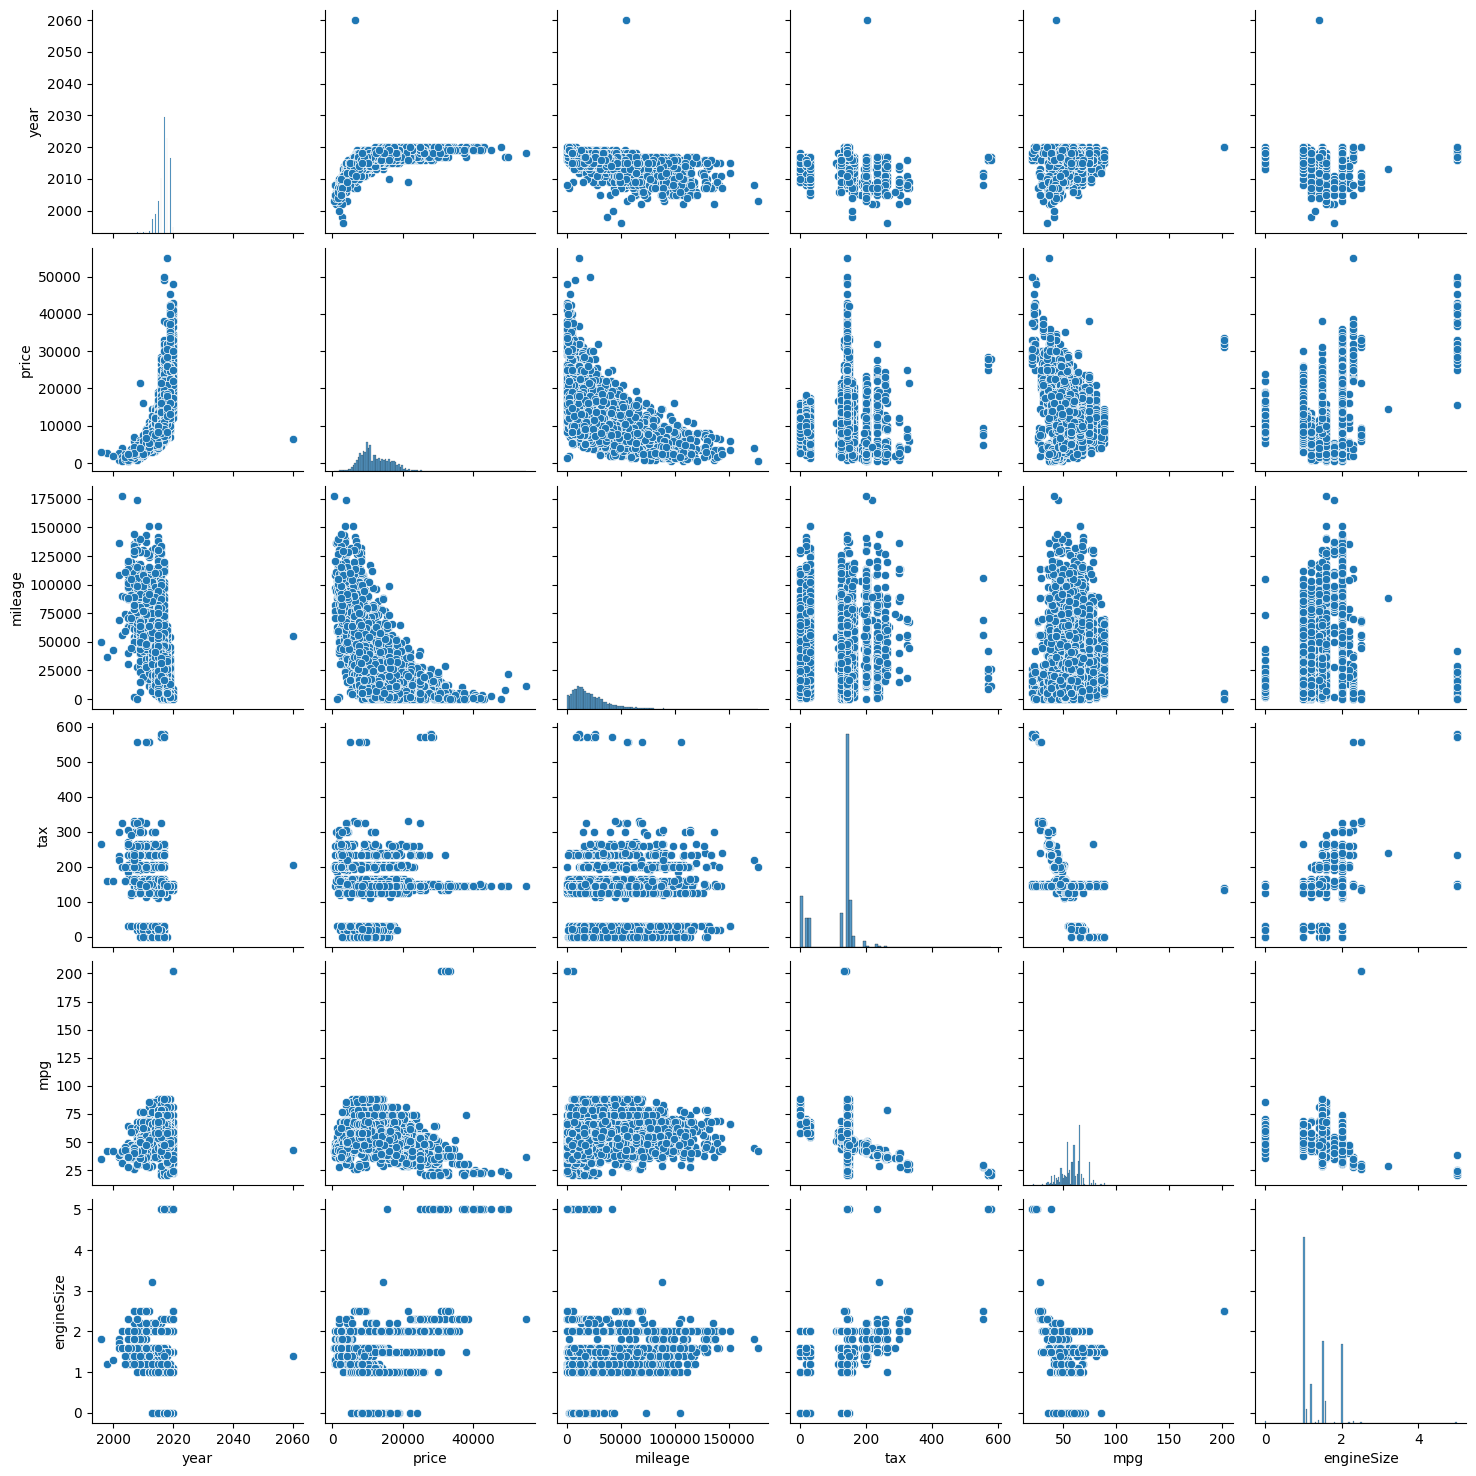

In [ ]:
sns.pairplot(data = df)

***Check Outliers.***

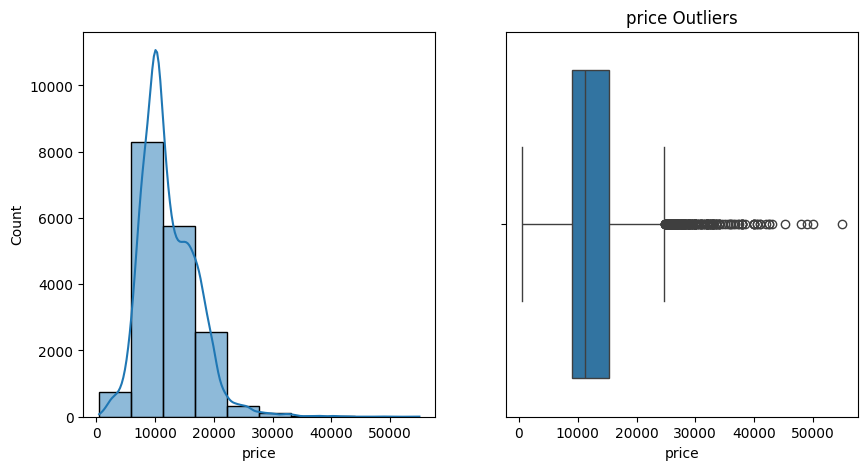

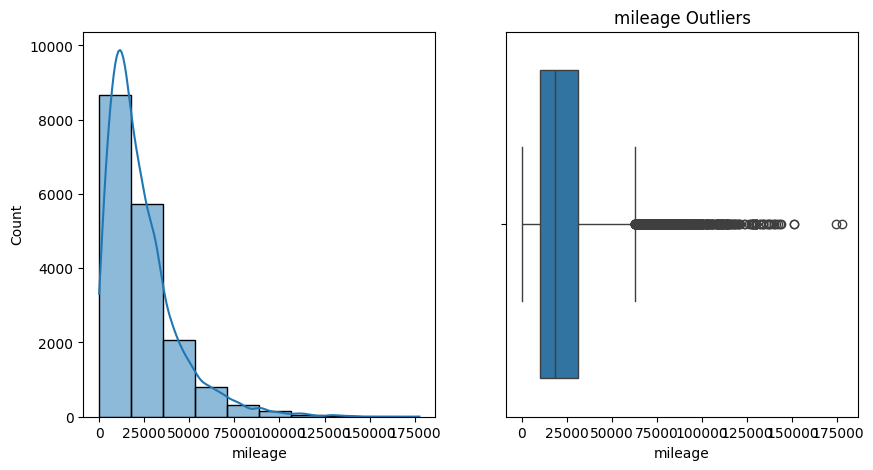

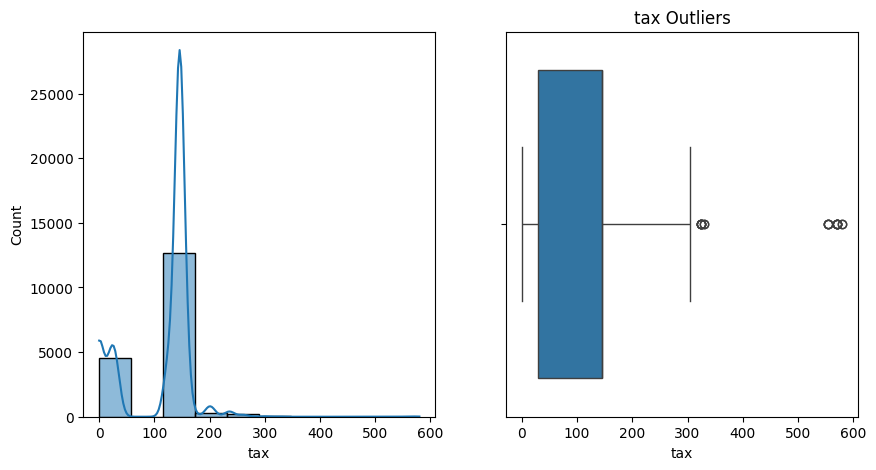

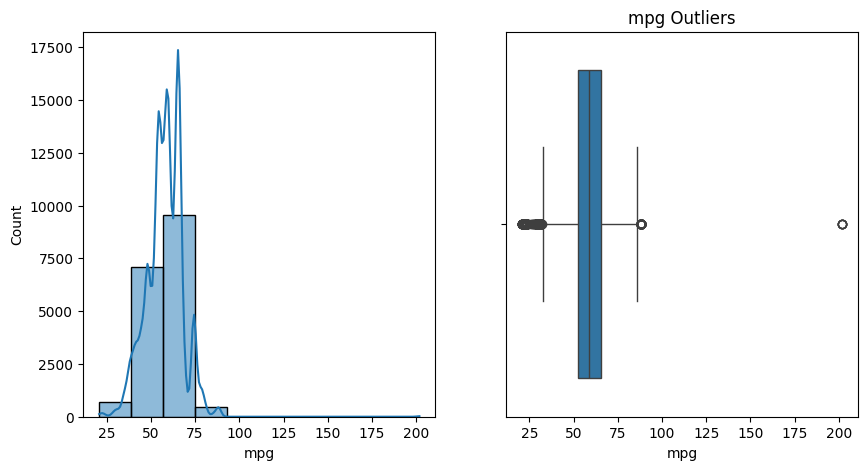

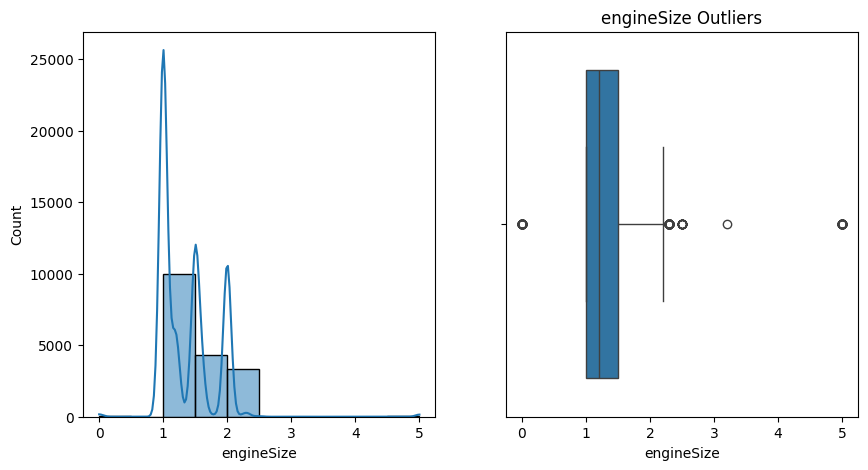

In [ ]:
columns = df[['price','mileage','tax','mpg','engineSize']].copy()
for column in columns:
  plt.figure(figsize = (10,5))
  plt.subplot(1,2,1)
  sns.histplot(df[column], bins = 10, kde = True)
  plt.subplot(1,2,2)
  sns.boxplot(x = df[column])
  plt.title(f'{column} Outliers')
  plt.show()

***Remove Outliers from IQR Method in the price column.***

In [ ]:
percentile25 = columns['price'].quantile(0.25)
percentile75 = columns['price'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

Percentile25 = 8999.0
Percentile75 = 15295.0


In [ ]:
iqr = percentile75 - percentile25
print("IQR =", iqr)

IQR = 6296.0


In [ ]:
upper_limit = percentile75 + 1.4 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper Limit =", upper_limit)
print("Lower Limit =", lower_limit)

Upper Limit = 24109.4
Lower Limit = -445.0


In [ ]:
columns[columns['price'] > upper_limit]

,price,mileage,tax,mpg,engineSize
8,25500,6894,145,42.2,2.0
91,24995,7997,235,36.7,2.3
230,34498,4623,145,43.5,2.0
302,42489,3500,145,22.1,5.0
339,38489,3500,145,30.7,2.3
...,...,...,...,...,...
17838,30000,1000,145,43.5,2.0
17866,48000,50,145,23.9,5.0
17868,25050,50,145,38.2,2.0
17890,25999,19458,145,47.9,2.0


In [ ]:
columns[columns['price'] < lower_limit]

,price,mileage,tax,mpg,engineSize


***Trimming.***

In [ ]:
x = columns[(df['price'] < upper_limit) & (columns['price'] > lower_limit)]
x.shape

(17508, 5)

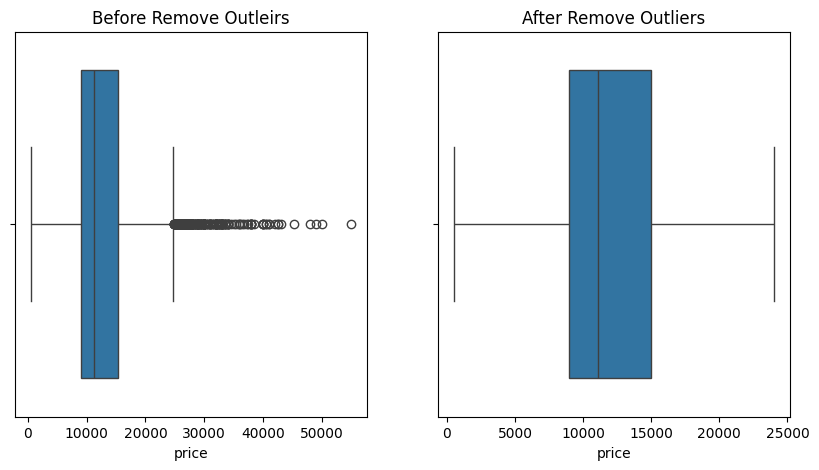

In [ ]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.boxplot(x = columns['price'])
plt.title("Before Remove Outleirs")

plt.subplot(1,2,2)
sns.boxplot(x = x['price'])
plt.title("After Remove Outliers")
plt.show()

***Remove Outliers from IQR Method in the Mileage Column.***

In [ ]:
percentile25 = columns['mileage'].quantile(0.25)
percentile75 = columns['mileage'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

Percentile25 = 10000.0
Percentile75 = 31098.5


In [ ]:
iqr = percentile75 - percentile25
print("IQR =",iqr)

IQR = 21098.5


In [ ]:
upper_limit = percentile75 + 1.1 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper Limit =", upper_limit)
print("Lower Limit =", lower_limit)

Upper Limit = 54306.850000000006
Lower Limit = -21647.75


***Trimming.***

In [ ]:
x = columns[(df['mileage'] < upper_limit) & (columns['mileage'] > lower_limit)]
x.shape

(16520, 5)

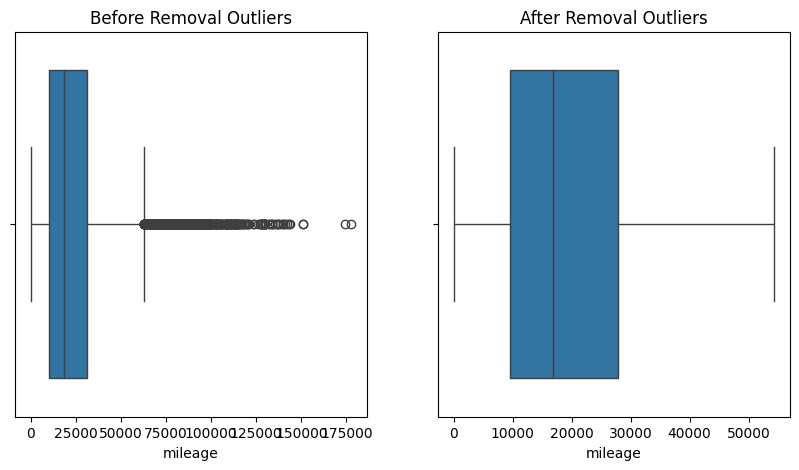

In [ ]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.boxplot(x = columns['mileage'])
plt.title("Before Removal Outliers")

plt.subplot(1,2,2)
sns.boxplot(x = x['mileage'])
plt.title("After Removal Outliers")
plt.show()

***Remove Outliers from IQR Method in the Tax Column.***

In [ ]:
percentile25 = columns['tax'].quantile(0.25)
percentile75 = columns['tax'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

Percentile25 = 30.0
Percentile75 = 145.0


In [ ]:
iqr = percentile75 - percentile25
print("IQR =", iqr)

IQR = 115.0


In [ ]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper Limit =", upper_limit)
print("Lower Limit =", lower_limit)

Upper Limit = 317.5
Lower Limit = -142.5


***Trimming.***

In [ ]:
x = columns[(df['tax'] < upper_limit) & (columns['tax'] > lower_limit)]
x.shape

(17792, 5)

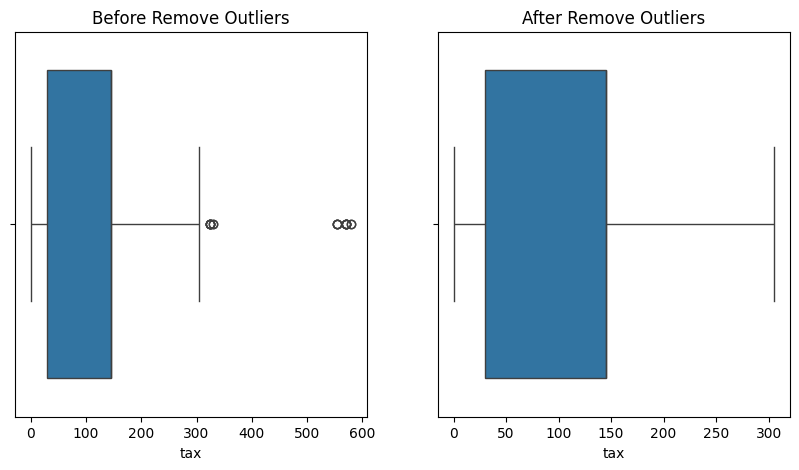

In [ ]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.boxplot(x = columns['tax'])
plt.title("Before Remove Outliers")

plt.subplot(1,2,2)
sns.boxplot(x = x['tax'])
plt.title("After Remove Outliers")
plt.show()

***Remove Outliers from IQR Method in the MPG Column.***

In [ ]:
percentile25 = columns['mpg'].quantile(0.25)
percentile75 = columns['mpg'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

Percentile25 = 52.3
Percentile75 = 65.7


In [ ]:
iqr = percentile75 - percentile25
print("IQR =", iqr)

IQR = 13.400000000000006


In [ ]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper Limit =", upper_limit)
print("Lower Limit =", lower_limit)

Upper Limit = 85.80000000000001
Lower Limit = 32.19999999999999


***Trimming.***

In [ ]:
x = columns[(df['mpg'] < upper_limit) & (columns['mpg'] > lower_limit)]
x.shape

(17596, 5)

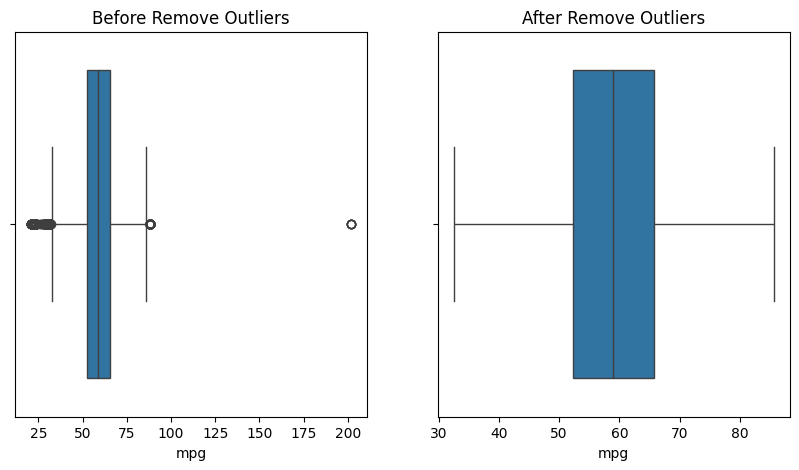

In [ ]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.boxplot(x = columns['mpg'])
plt.title("Before Remove Outliers")

plt.subplot(1,2,2)
sns.boxplot(x = x['mpg'])
plt.title("After Remove Outliers")
plt.show()

***Remove outliers from IQR in the engineSize.***

In [ ]:
percentile25 = columns['engineSize'].quantile(0.25)
percentile75 = columns['engineSize'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

Percentile25 = 1.0
Percentile75 = 1.5


In [ ]:
iqr = percentile75 - percentile25
print("IQR =", iqr)

IQR = 0.5


In [ ]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper limit =", upper_limit)
print("Lower limit =", lower_limit)

Upper limit = 2.25
Lower limit = 0.25


***Trimming.***

In [ ]:
x = columns[(df['engineSize'] < upper_limit) & (columns['engineSize'] > lower_limit)]
x.shape

(17622, 5)

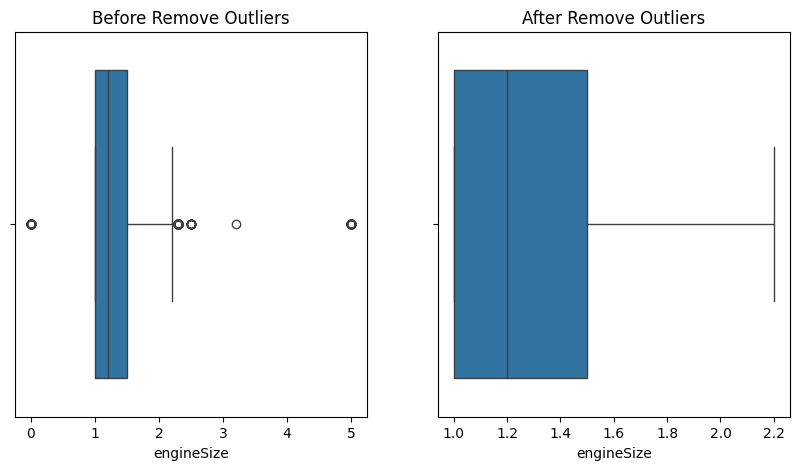

In [ ]:
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.boxplot(x = columns['engineSize'])
plt.title("Before Remove Outliers")

plt.subplot(1,2,2)
sns.boxplot(x = x['engineSize'])
plt.title("After Remove Outliers")
plt.show()

***Create Dummy Variable.***

In [ ]:
df_clean = pd.get_dummies(df, columns = ['model','transmission','fuelType'])
df_clean

,year,price,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,15944,150,57.7,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
1,2018,14000,9083,150,57.7,1.0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,2017,13000,12456,150,57.7,1.0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2019,17500,10460,145,40.3,1.5,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,2019,16500,1482,145,48.7,1.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47.1,1.4,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
17962,2014,7499,40700,30,57.7,1.0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
17963,2015,9999,7010,20,67.3,1.6,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
17964,2018,8299,5007,145,57.7,1.2,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
x = df_clean.drop('price',axis = 1)
y = df_clean['price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_predict = model.predict(x_test)

In [ ]:
accuracy = r2_score(y_test, y_predict)
print(f"Final Model Accuracy (R-squared): {accuracy:.2f}")

Final Model Accuracy (R-squared): 0.82


In [ ]:
print(model.score(x_train, y_train))

0.8479124123905243


In [ ]:
print(model.score(x_test, y_test))

0.8188919779971339


In [ ]:
row_no = int(input("Enter the predicted row numbers = "))
test_value = x_test.iloc[[row_no]]
real_price = y_test.iloc[row_no]
prediction = model.predict(test_value)
defference = abs(real_price - prediction)
print(f"Row Number {row_no} Result")
print(f"Real Price = {real_price:.2f}")
print(f"Prediction Price = {prediction[0]:.2f}")
print(f"Difference = {defference[0]:.2f}")

Enter the predicted row numbers = 10
Row Number 10 Result
Real Price = 10340.00
Prediction Price = 11565.98
Difference = 1225.98
